In [91]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [92]:
df = pd.read_csv('datasets/minute maid_from_dump.csv')

In [93]:
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,0025000034824,"Minute maid, sparkling juice drink, fruit punch",Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",NaN,NaN,NaN,c,4.0,NaN,"Carbonated water, grape and apple juices from ...",NaN,NaN
1,0025000047244,Fruit Cooler Lemonade,Minute Maid,"beverages, carbonated-drinks, sodas, lemonade",france,NaN,NaN,NaN,e,NaN,NaN,NaN,NaN,NaN
2,0025000056017,100% Apple Juice,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",united-states,NaN,NaN,NaN,unknown,NaN,c,NaN,NaN,NaN
3,0025000056031,100% Orange Juice,Minute Maid,"beverages-and-beverages-preparations, plant-ba...",united-states,NaN,NaN,California,e,1.0,a,"pure filtered water, concentrated orange juice...",10.0,48.9
4,0025000058073,Lemonade,Minute Maid,"beverages-and-beverages-preparations, beverage...",france,NaN,NaN,NaN,e,4.0,NaN,"Pure filtered water, high fructose corn syrup,...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,01070965,Minute maid,NaN,NaN,france,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
681,6975682483042,MZY Peach Juice Drink,"Minute Maid, Coca-Cola, MZY","beverages-and-beverages-preparations, plant-ba...","china, united-kingdom",NaN,NaN,NaN,e,4.0,NaN,"Water, fructose syrup, sugar, concentrated pea...",NaN,NaN
682,9416216001433,Minute Maid Pulpy,Orange,NaN,fiji,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
683,4902102060646,Apple 100%,Minute Maid,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


# *Cleaning and Exploring Data

In [94]:
df.rename(columns={'nutriments.sugars_100g': 'sugars_100g'}, inplace=True)
df.rename(columns={'nutriments.energy-kcal_100g': 'energy_kcal_100g'}, inplace=True)

In [95]:
df.sugars_100g.unique()

array([         nan,  10.        ,  11.7       ,  10.73      ,
        11.        ,   7.91      ,   8.5       ,  13.1       ,
        12.        ,   4.17      ,  11.8644    ,  12.3       ,
        27.        ,   9.29      ,  10.42      ,   6.27      ,
         0.        ,  12.5       ,  23.75      ,  10.2       ,
        50.        ,   9.58      ,   9.16666667,  12.08333333,
        12.4       ,  11.25      ,   7.08      ,  10.17      ,
        11.86      ,  10.32      ,  11.3       ,  48.33      ,
        60.        ,  33.33      ,  40.        ,  51.11      ,
         0.83      ,  11.67      ,  24.        ,   7.08333333,
        11.34882294,   1.2       ,   1.4       ,   8.33333333,
        46.67      ,  12.08      ,   6.4       ,   9.3       ,
        10.1695    ,  13.5       ,  10.83333333,  10.42253521,
        54.        ,  11.26760563,  18.46153846,  19.23076923,
         4.16666667,  10.58201058,  19.84732824,   8.23529412,
        10.70422535,   2.17391304,   7.90960452,  10.73

In [96]:
df.energy_kcal_100g.value_counts()

energy_kcal_100g
0.000000      22
45.833333      8
0.676000       5
148.000000     5
36.000000      5
              ..
28.169014      1
6.521739       1
50.732807      1
45.197740      1
15.200000      1
Name: count, Length: 167, dtype: int64

In [97]:
df.ecoscore_grade.value_counts()

ecoscore_grade
unknown           114
not-applicable      9
c                   7
e                   5
d                   5
a                   3
Name: count, dtype: int64

In [98]:
df.columns

Index(['code', 'product_name', 'brands', 'categories_tags', 'countries_tags',
       'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade',
       'nova_group', 'ecoscore_grade', 'ingredients_text', 'sugars_100g',
       'energy_kcal_100g'],
      dtype='object')

In [99]:
df.dtypes

code                 object
product_name         object
brands               object
categories_tags      object
countries_tags       object
packaging_tags       object
stores               object
purchase_places      object
nutriscore_grade     object
nova_group          float64
ecoscore_grade       object
ingredients_text     object
sugars_100g         float64
energy_kcal_100g    float64
dtype: object

In [100]:
df.code.unique()

array(['0025000034824', '0025000047244', '0025000056017', '0025000056031',
       '0025000058073', '0025000061516', '0025000061530', '0025000063213',
       '0059600048134', '0059600060594', '0059600061904', '0059600061942',
       '0059600070159', '0059600070241', '0059600070876', '0059600070937',
       '00817141', '02505008', '02520609', '05965930', '11206388',
       '11218368', '2000000003788', '32346565', '3292090941579',
       '3292090941692', '3409664796026', '40822716', '42094418',
       '42104773', '4710018146305', '4890008200511', '54008304',
       '5449000002860', '5449000018656', '5449000034274', '5449000045614',
       '5449000045621', '5449000056313', '5449000067357', '5449000098870',
       '5449000100573', '5449000101068', '5449000111067', '5449000111104',
       '5449000136039', '5449000136060', '5449000136084', '5449000136398',
       '5449000136404', '5449000137586', '5449000142573', '5449000149596',
       '5449000156365', '5449000156389', '5449000176820', '5449

In [101]:
df.code[df.duplicated()]

Series([], Name: code, dtype: object)

In [102]:
df.isnull().sum()

code                  0
product_name         10
brands               51
categories_tags     256
countries_tags        0
packaging_tags      618
stores              659
purchase_places     646
nutriscore_grade      0
nova_group          498
ecoscore_grade      542
ingredients_text    294
sugars_100g         344
energy_kcal_100g    341
dtype: int64

In [103]:
df.packaging_tags.fillna('unknown')

0      unknown
1      unknown
2      unknown
3      unknown
4      unknown
        ...   
680    unknown
681    unknown
682    unknown
683    unknown
684    unknown
Name: packaging_tags, Length: 685, dtype: object

In [104]:
df.stores = df.stores.fillna('unknown')
df.purchase_places = df.purchase_places.fillna('unknown')
df.ecoscore_grade = df.ecoscore_grade .fillna('unknown')
df.ingredients_text = df.ingredients_text.fillna('unknown')
df.categories_tags = df.categories_tags.fillna('unknown')
df.brands = df.brands.fillna('unknown')
df.product_name = df.product_name.fillna('unknown')
df.packaging_tags = df.packaging_tags.fillna('unknown')

In [105]:
df.isnull().sum()

code                  0
product_name          0
brands                0
categories_tags       0
countries_tags        0
packaging_tags        0
stores                0
purchase_places       0
nutriscore_grade      0
nova_group          498
ecoscore_grade        0
ingredients_text      0
sugars_100g         344
energy_kcal_100g    341
dtype: int64

In [106]:
df.countries_tags.unique()

array(['france, united-states', 'france', 'united-states',
       'saint-pierre-and-miquelon', 'canada, france', 'canada',
       'france, martinique, switzerland', 'belgium, france, luxembourg',
       'taiwan', 'hong-kong', 'belgium, france', 'belgium',
       'belgium, france, martinique, switzerland', 'france, spain',
       'belgium, france, world', 'united-kingdom', 'spain', 'thailand',
       'india', 'france, luxembourg', 'belgium, france, germany',
       'belgium, france, switzerland', 'belgium, france, reunion',
       'france, spain, united-states', 'canada, switzerland',
       'martinique', 'switzerland', 'france, world', 'germany',
       'belgium, world', 'singapore', 'france, united-states, world',
       'senegal', 'united-states, world', 'mexico', 'canada, germany',
       'ireland', 'aruba', 'puerto-rico', 'luxembourg', 'kenya',
       'jamaica', 'philippines', 'barbados', 'ethiopia', 'suriname',
       'malaysia', 'mayotte', 'trinidad-and-tobago', 'norway', 'japan'

In [107]:
df_clean = df.countries_tags.str.split(',').explode('countries_tags')
df_clean = df_clean.str.strip()
df_clean

0              france
1       united-states
2              france
3       united-states
4       united-states
            ...      
752             china
753    united-kingdom
754              fiji
755     united-states
756             japan
Name: countries_tags, Length: 757, dtype: object

In [108]:
df_clean.value_counts()

countries_tags
united-states                          360
france                                 152
canada                                  68
belgium                                 31
philippines                             16
world                                   16
spain                                   13
india                                   13
ireland                                 11
germany                                  8
japan                                    7
thailand                                 7
switzerland                              5
luxembourg                               5
singapore                                4
martinique                               4
netherlands                              4
hong-kong                                3
united-kingdom                           3
china                                    2
kenya                                    2
malaysia                                 2
virgin-islands-of-the-united-states    

In [109]:
df_clean.nunique()

43

# Stores , Ingredienets Data , Purchase place
## Insights

There are not enough information available about the above columns in dataset


In [110]:
df.ingredients_text.value_counts()

ingredients_text
unknown                                                                                                                                                                                                                                                                                                                                                                                                           294
undefined                                                                                                                                                                                                                                                                                                                                                                                                         175
100% orange juice from concentrate contains pure filtered water, premium concentrated orange juice.                                                                        

# Top 5 Countries by Average Energy (kcal)

## Insights :

Jamaica leads the chart with the highest average energy intake at ~240 kcal.

Barbados (~180 kcal) and Romania (~178 kcal) follow closely in second and third place.

Trinidad and Tobago ranks fourth with an average of 150 kcal.

Luxembourg rounds out the top five at the lowest level (~122 kcal), roughly half of Jamaica's value.

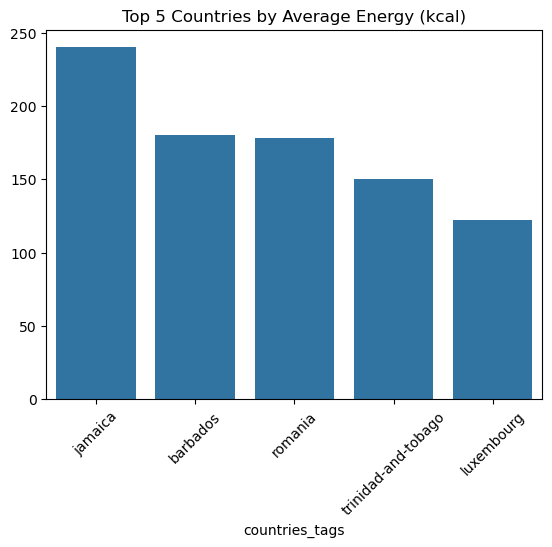

In [111]:
top5 = df.groupby('countries_tags')['energy_kcal_100g'].mean().nlargest(5)

sns.barplot(x=top5.index, y=top5.values)
plt.xticks(rotation=45)
plt.title('Top 5 Countries by Average Energy (kcal)')
plt.show()

# Top 5 Countries by Average Suger Content

## Insights

Jamaica ranks highest with an average sugar content of 60g per 100g.

Barbados (~44g) and Trinidad and Tobago (~38g) follow in second and third place.

Luxembourg places fourth with an average of 26g per 100g.

United States has the lowest value among the top five at approximately 13g per 100g (less than a quarter of Jamaica's content).

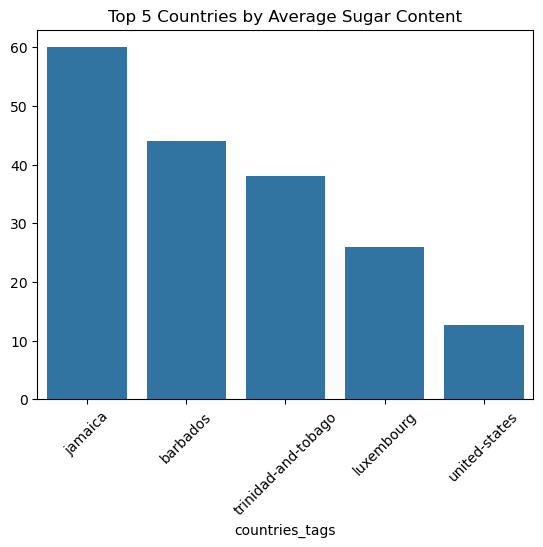

In [112]:
top5 = df.groupby('countries_tags')['sugars_100g'].mean().nlargest(5)

sns.barplot(x=top5.index, y=top5.values)
plt.xticks(rotation=45)
plt.title('Top 5 Countries by Average Sugar Content')
plt.show()

# Top 10 Product Distribution Across Countries

## Insights 

United States heavily dominates the dataset with 360 entries, accounting for more than double the second-place country.

France (152) and Canada (68) form the primary mid-tier, showing a steep drop-off after North America and Western Europe's top entries.

Belgium (31), Philippines (16), and World (16) trail significantly, each contributing a fraction of the top volume.

Long Tail Distribution: The remaining countries in the top 10 (Spain, India, Ireland, Germany) taper off sharply into single-to-low-double digits ($\le$13 entries).

countries_tags
united-states                          360
france                                 152
canada                                  68
belgium                                 31
philippines                             16
world                                   16
spain                                   13
india                                   13
ireland                                 11
germany                                  8
japan                                    7
thailand                                 7
switzerland                              5
luxembourg                               5
singapore                                4
martinique                               4
netherlands                              4
hong-kong                                3
united-kingdom                           3
china                                    2
kenya                                    2
malaysia                                 2
virgin-islands-of-the-united-states    

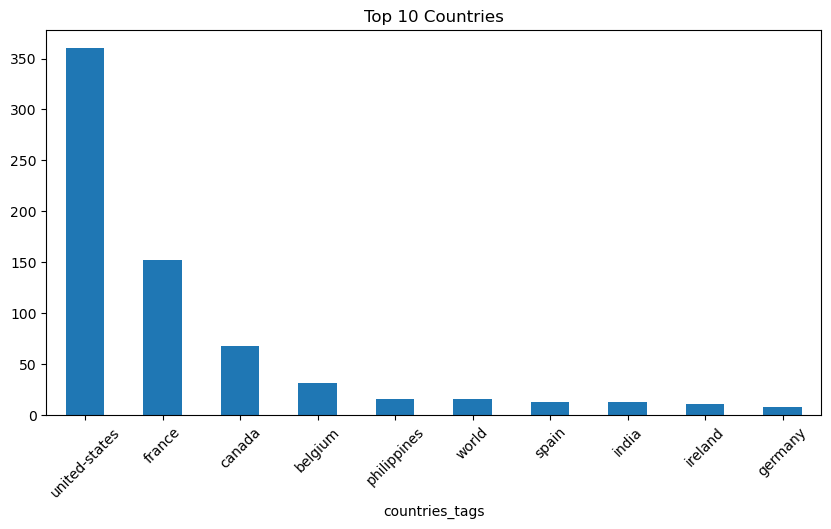

In [24]:

df_clean = df['countries_tags'].str.split(',').explode().str.strip()
countries_graph = df_clean.value_counts()
display(countries_graph)
countries_graph.head(10).plot(kind='bar', figsize=(10,5), title='Top 10 Countries')

plt.xticks(rotation=45)
plt.show()

In [25]:
df_clean

0              france
0       united-states
1              france
2       united-states
3       united-states
            ...      
681             china
681    united-kingdom
682              fiji
683     united-states
684             japan
Name: countries_tags, Length: 757, dtype: object

In [26]:
df_cleanpt = df.packaging_tags.str.split(',').explode('packaging_tags')
df_cleanpt = df_cleanpt.str.strip()
df_cleanpt

0      unknown
1      unknown
2      unknown
3      unknown
4      unknown
        ...   
726    unknown
727    unknown
728    unknown
729    unknown
730    unknown
Name: packaging_tags, Length: 731, dtype: object

In [39]:
df_cleanpt.value_counts()

packaging_tags
unknown                          618
bottle                            18
can                               14
drink-can                         12
plastic                           12
tetra-pak                          6
cardboard                          5
brick                              5
metal                              4
tetra-brik-aseptic                 4
multilayer-composite               3
tetra-brik                         2
glass                              2
aluminium                          2
recyclable-metals                  2
pet-bottle                         2
plastic-bottle                     2
container                          1
bouteille-en-verre                 1
tetra-pac                          1
paper-based-carton                 1
bottle-or-vial                     1
conserve                           1
gold-bricks                        1
1-canette-en-metal-a-recycler      1
brique                             1
th:ขวดพลาสติก          

In [40]:
df_cleanpt.nunique()

35

# Insights 

* **Standardized Inconsistent & Multilingual Tags:** Merged raw variants, synonyms, and foreign terms (e.g., French `bouteille-en-verre`, Thai `th:ขวดพลาสติก`, `tetra-pak`, `pet-bottle`) into uniform material categories like **Plastic**, **Glass**, **Metal**, and **Composite**.
* **Reduced Noise & Cardinality:** Grouped 35+ fragmented, messy tags into 6–7 clean groups, filtering out irrelevant attributes (`orange`, `pasteurized`) into **Other** and missing data into **Unknown**.
* **Enabled Meaningful Aggregation:** Prevents identical materials from splitting across separate values, making downstream charts, counts, and statistical analysis clean, accurate, and readable.

In [41]:
packaging_groups = {
    # Plastic
    'pet-bottle': 'Plastic',
    'plastic': 'Plastic',
    'plastic-bottle': 'Plastic',
    'th:ขวดพลาสติก': 'Plastic',

    # Glass
    'glass': 'Glass',
    'bouteille-verre': 'Glass',
    'bouteille-en-verre': 'Glass',
    'bouteille-consignee': 'Glass',

    # Metal
    'can': 'Metal',
    'drink-can': 'Metal',
    'metal': 'Metal',
    'recyclable-metals': 'Metal',
    'aluminium': 'Metal',
    'conserve': 'Metal',
    '1-canette-en-metal-a-recycler': 'Metal',

    # Paper & Cardboard
    'cardboard': 'Paper/Cardboard',
    'paper-based-carton': 'Paper/Cardboard',
    'card': 'Paper/Cardboard',
    'box': 'Paper/Cardboard',

    # Composite / Beverage Cartons
    'brick': 'Composite',
    'brique': 'Composite',
    'tetra-pak': 'Composite',
    'tetra-brik-aseptic': 'Composite',
    'tetra-brik': 'Composite',
    'tetra-pac': 'Composite',
    'multilayer-composite': 'Composite',
    'gold-bricks': 'Composite',

    # Generic Bottles / Vials (Unspecified Material)
    'bottle': 'Bottle (Unspecified)',
    'bottle-or-vial': 'Bottle (Unspecified)',
    'th:ขวด': 'Bottle (Unspecified)',

    # Unknown & Other
    'unknown': 'Unknown',
    'pasteurized': 'Other',
    'tumbler': 'Other',
    'container': 'Other',
    'orange': 'Other'
}
df['packaging_group'] = df['packaging_tags'].map(packaging_groups).fillna('Other')

In [42]:
df['packaging_group'].value_counts()

packaging_group
Unknown                 618
Other                    35
Bottle (Unspecified)      9
Plastic                   8
Composite                 7
Metal                     4
Paper/Cardboard           2
Glass                     2
Name: count, dtype: int64

# Packaging Tags / Country

## Insights

* **Bottle & Plastic Dominance:** Bottled packaging (9) and explicit Plastic items (8) make up the majority of categorized products, showing a strong reliance on rigid plastic/bottle-type formats.
* **Significant Composite Presence:** Composite materials (Tetra-paks/aseptic cartons) rank third with 7 items, making multi-layer beverage packaging a major format.
* **Low Representation for Glass & Paper:** Eco-friendly and traditional materials like Glass (2) and Paper/Cardboard (2) are the least common in the dataset.
* **Canned Metal Formats:** Metal packaging (cans) holds a moderate presence with 4 items, sitting between composite cartons and glass/paper.

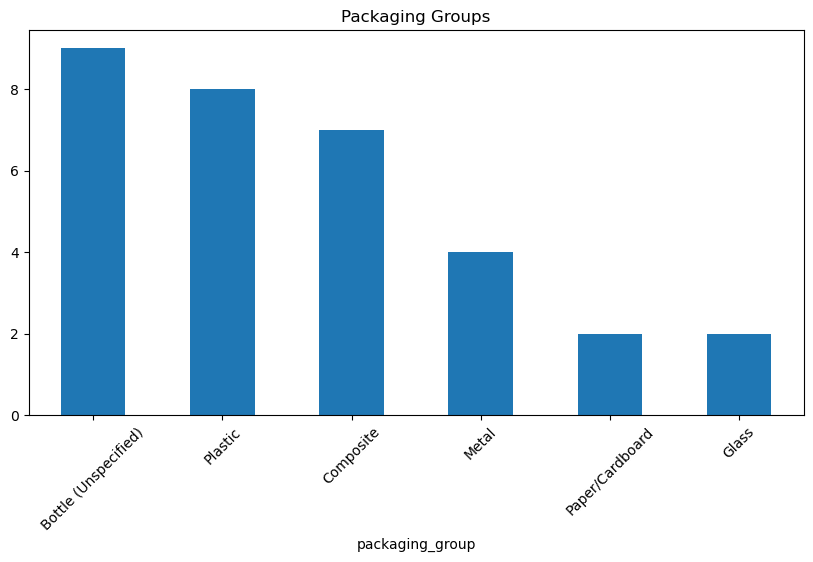

In [43]:
packaging_graph = df['packaging_group'].value_counts().drop(['Unknown', 'Other'], errors='ignore')

packaging_graph.plot(kind='bar', figsize=(10, 5), title='Packaging Groups')
plt.xticks(rotation=45)
plt.show()

In [44]:
df.nutriscore_grade.unique()

array(['c', 'e', 'unknown', 'd', 'b'], dtype=object)

In [45]:
df.nutriscore_grade.value_counts()

nutriscore_grade
unknown    316
e          144
b          102
c           83
d           40
Name: count, dtype: int64

# Nutriscore Grade Distribution

## Insights

 
 Grade 'e' Leads Known Values: Among classified products, Grade e is the most frequent (~144 items), followed by b (~102 items) and c (~83 items).
 
 Grade 'd' is Least Represented: Grade d has the lowest count among the visible grades at approximately 40 items.
 
 Completely Missing Grade 'a': The highest nutritional quality category (Grade a) is entirely absent from the distribution.

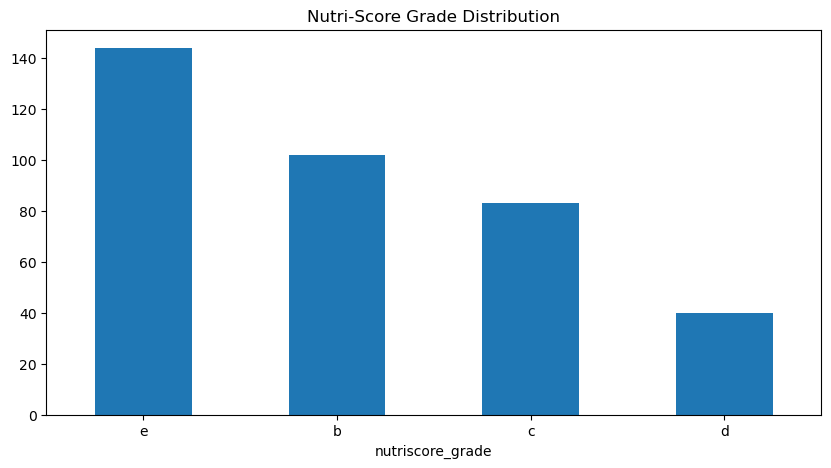

In [46]:
df.nutriscore_grade.value_counts().drop('unknown', errors='ignore').plot(
    kind='bar',
    figsize=(10,5),
    title='Nutri-Score Grade Distribution'
)

plt.xticks(rotation=0)
plt.show()

Dominant Missingness: With 316 unknown entries, unclassified data accounts for nearly 46% of the entire dataset ($\approx 685$ total rows), outnumbering any single recorded grade.

In [47]:
df.columns

Index(['code', 'product_name', 'brands', 'categories_tags', 'countries_tags',
       'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade',
       'nova_group', 'ecoscore_grade', 'ingredients_text', 'sugars_100g',
       'energy_kcal_100g', 'packaging_group'],
      dtype='object')

In [48]:
df.nova_group

0      4.0
1      NaN
2      NaN
3      1.0
4      4.0
      ... 
680    NaN
681    4.0
682    NaN
683    NaN
684    NaN
Name: nova_group, Length: 685, dtype: float64

In [49]:
df.nova_group.unique()

array([ 4., nan,  1.,  3.])

In [50]:
df['nova_group'].isna().sum()

np.int64(498)

# Nova Group

## Insights


Ultra-Processed Foods Dominate (Group 4.0): Among known records, Group 4.0 (ultra-processed food) is the largest category by far with 133 items (~71.1% of valid data).

Unprocessed/Minimally Processed (Group 1.0): The second-largest category is Group 1.0 with 50 items (~26.7% of valid data).

Sparse Group 3.0 & Missing Group 2.0: Group 3.0 (processed foods) is rare with only 4 items (~2.1%), while Group 2.0 (processed culinary ingredients) is completely absent.

In [51]:
df.nova_group.value_counts()

nova_group
4.0    133
1.0     50
3.0      4
Name: count, dtype: int64

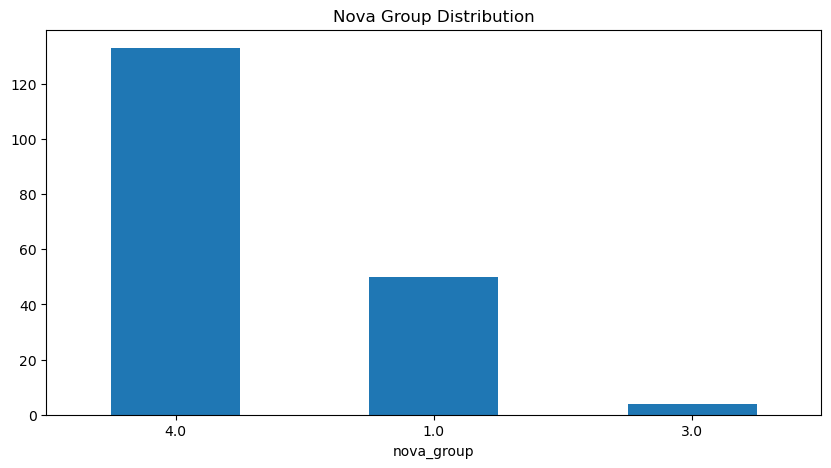

In [52]:
NovaGroup = df.nova_group.value_counts().plot(
    kind='bar',
    figsize=(10,5),
    title='Nova Group Distribution'
)

plt.xticks(rotation=0)
plt.show()

High Proportion of Missing Data: A massive 498 values are missing (NaN), accounting for approximately 72.7% of the entire dataset (187 non-null out of 685 total entries).

In [53]:
top_10_countries = df['countries_tags'].value_counts().nlargest(10).index
df_top10 = df[df['countries_tags'].isin(top_10_countries)]

In [54]:
top_10_countries

Index(['united-states', 'france', 'canada', 'philippines', 'belgium, france',
       'india', 'ireland', 'united-states, world', 'belgium',
       'france, united-states'],
      dtype='object', name='countries_tags')

In [55]:
df.stores.unique()

array(['unknown', 'Jewel Osco', "McDonald's", 'Delhaize', 'Supermarket',
       'Magasins U', 'Noz', 'Distributeur', 'Carrefour City', 'colruyt',
       'Aéroport de Charleroi-Bruxelles-Sud', 'Eurodisney', 'Dollarama',
       'Walmart,Real Canadian Superstore', 'auchan', 'Urban Fare',
       'Walmart', 'Real Canadian Superstore', 'Store,Supermarkets',
       'Supermarket,SM,7-Eleven', 'Burger King', 'Maxi'], dtype=object)

In [56]:
df.stores.nunique()

22

In [57]:
df['stores'].isna().sum()

np.int64(0)

In [58]:
df.purchase_places.unique()

array(['unknown', 'California', 'Saint Pierre et Miquelon',
       'Chicago,Illinois,USA', 'Pennsylvania', 'Paris,France', 'Taipei',
       'Hong Kong', 'Belgium', 'Courrières,France', 'Lyon,France',
       'Marseille,France', 'Madrid,España', 'France',
       'Belgique,Charleroi', 'Kharagpur,West Bengal,India', 'rochefort',
       'United States', 'Calgary,Alberta,Canada', 'Singapore', 'India',
       'Philippines', 'Quebec Canada'], dtype=object)

In [59]:
df.purchase_places.nunique()

23

In [60]:
usa = df[df['countries_tags'] == 'en:united-states']

In [61]:
df['countries_tags'].value_counts().head(20)


countries_tags
united-states            341
france                   107
canada                    59
philippines               16
belgium, france           15
india                     13
ireland                   11
united-states, world       8
belgium                    8
france, united-states      8
japan                      7
thailand                   7
spain                      7
france, spain              5
canada, germany            4
canada, france             4
singapore                  4
netherlands                4
hong-kong                  3
world                      3
Name: count, dtype: int64

# USA Country Analysis


In [62]:
usa = df[df['countries_tags'].str.contains("united-states")]
usa

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,sugars_100g,energy_kcal_100g,packaging_group
0,0025000034824,"Minute maid, sparkling juice drink, fruit punch",Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",unknown,unknown,unknown,c,4.0,unknown,"Carbonated water, grape and apple juices from ...",NaN,NaN,Unknown
2,0025000056017,100% Apple Juice,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",united-states,unknown,unknown,unknown,unknown,NaN,c,unknown,NaN,NaN,Unknown
3,0025000056031,100% Orange Juice,Minute Maid,"beverages-and-beverages-preparations, plant-ba...",united-states,unknown,unknown,California,e,1.0,a,"pure filtered water, concentrated orange juice...",10.0,48.9,Unknown
5,0025000061516,100% apple juice,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",unknown,unknown,unknown,e,NaN,unknown,"CONTAINS PURE FILTERED WATER, CONCENTRATED APP...",NaN,NaN,Unknown
6,0025000061530,100% ORANGE JUICE,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",united-states,pet-bottle,unknown,unknown,e,1.0,unknown,"pure filtered water, concentrated orange juice...",NaN,NaN,Plastic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,4902102067041,アロエ & 白ぶどう,Minute Maid,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN,Unknown
673,4902102160407,SMOOTHIE PROTEIN ストロベリー,Minute Maid,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN,Unknown
674,4902102160438,SMOOTHIE PROTEIN,Minute Maid,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN,Unknown
677,4902102084642,朝バナナ (Morning Banana),Minute Maid,unknown,united-states,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN,Unknown


# Packaging Tags Distribution in the USA

# USA packaging tags

## Insights 

There are not much information available for packaging tags of USA country

# USA Nutri-Score Distribution

## insights


Top Nutritional Grades ('b' & 'e'): Grade b (94) and Grade e (88) dominate the filtered data, together accounting for nearly 75% of all classified products.

Moderate to Low Representation ('c' & 'd'): Grade c holds a moderate share with 48 items, while Grade d is the least represented with only 14 items.

Absence of Grade 'a': Similar to the broader dataset, the highest nutritional tier (Grade a) is completely missing.

Polarized Quality Distribution: Nutri-Score is split between high-tier Grade B (38.5%) and low-tier Grade E (36.1%), with very little middle ground (Grade D is just 5.7%).

In [63]:
usapp = usa.copy()

In [89]:
usapp.nutriscore_grade.value_counts()

nutriscore_grade
unknown    119
b           94
e           88
c           48
d           12
Name: count, dtype: int64

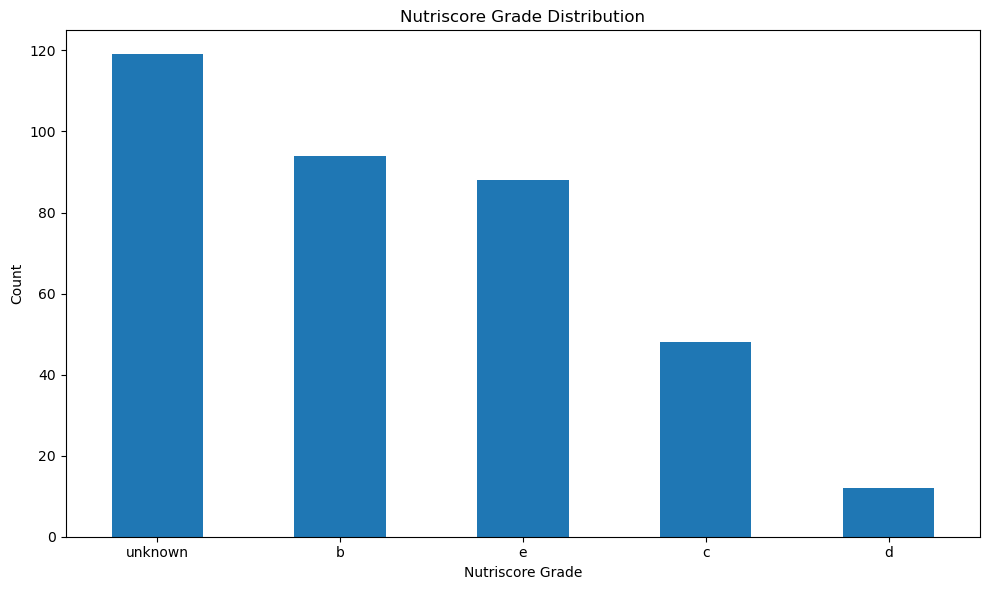

In [90]:
ncounts = usapp.nutriscore_grade.value_counts()

plt.figure(figsize=(10, 6))
ncounts.plot(kind='bar')
plt.title('Nutriscore Grade Distribution')
plt.xlabel('Nutriscore Grade')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

High Missing Data Filtered Out: Removing the 119 unknown entries left a clean subset of 244 labeled items for analysis.


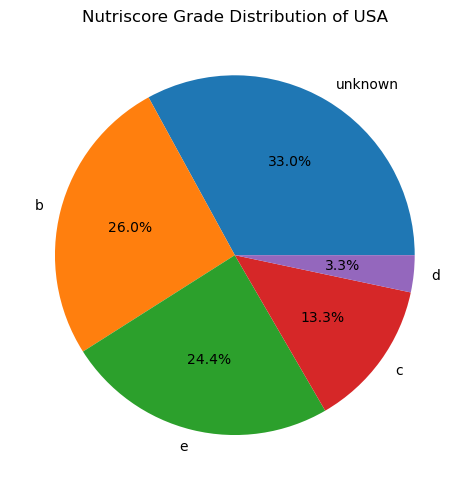

In [67]:
plt.figure(figsize=(5,5))
ncounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nutriscore Grade Distribution of USA')
plt.ylabel('')
plt.tight_layout()
plt.show()

# USA Nova group Analysis

## Insights

Dominance of Ultra-Processed Foods (Group 4.0): Ultra-processed items account for 71 entries (~81.6%) of the 87 total recorded values in this subset.

Unprocessed / Minimally Processed (Group 1.0): Only 16 items (~18.4%) belong to Group 1.0, representing less than a quarter of the ultra-processed volume.

Complete Absence of Groups 2.0 & 3.0: Neither processed culinary ingredients (Group 2.0) nor standard processed foods (Group 3.0) are present in this filtered distribution.



In [68]:
usappp = usa.copy()

In [69]:
usappp.nova_group.value_counts()

nova_group
4.0    71
1.0    16
Name: count, dtype: int64

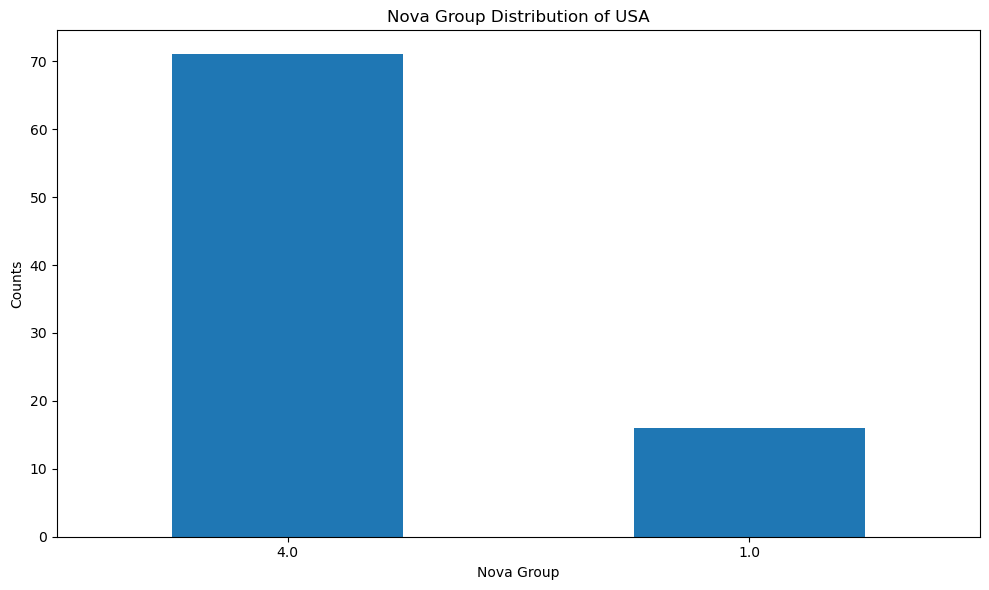

In [70]:
nvcounts = usappp.nova_group.value_counts()

plt.figure(figsize=(10,6))
nvcounts.plot(kind='bar')
plt.title('Nova Group Distribution of USA')
plt.xlabel('Nova Group')
plt.ylabel('Counts')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

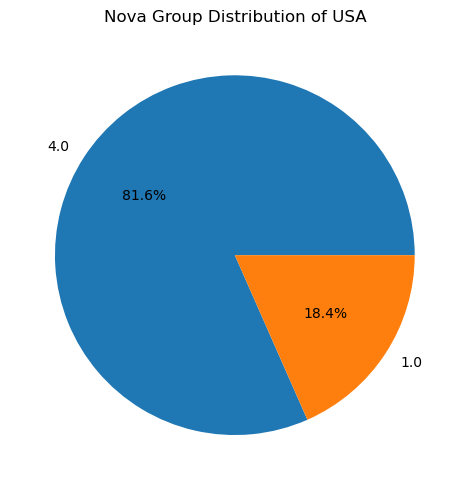

In [71]:
plt.figure(figsize=(5,5))
nvcounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nova Group Distribution of USA')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [72]:
usas = usa.copy()

# Suger per 100g 

In [73]:
usas.sugars_100g.value_counts()

sugars_100g
0.000000     64
10.000000    11
1.840000      7
1.270000      7
3.720000      5
             ..
2.480000      1
2.930000      1
1.740000      1
2.780000      1
10.416667     1
Name: count, Length: 125, dtype: int64

## Insights

* **Heavy Low-Sugar Concentration:** Over half of the products ($157$ out of $275$) contain $\le 5\text{g}$ of sugar per $100\text{g}$, with the largest segment sitting in the low-sugar $0.1\text{–}5\text{g}$ bracket ($93$ products) and a substantial zero-sugar group ($64$ products).
* **Secondary Mid-Level Peak:** A notable secondary cluster occurs in the $10\text{–}15\text{g}$ range ($43$ products), typical for sweetened beverages, juices, or lightly sweetened processed foods.
* **Low Representation in $15\text{–}20\text{g}$ Range:** Products sharply drop to their lowest count ($13$) in the $15\text{–}20\text{g}$ bracket before flattening out.
* **Long High-Sugar Tail:** High-sugar items ($>20\text{g}$) make up a steady minority across three tiers ($20$ in $20\text{–}30\text{g}$, $22$ in $30\text{–}50\text{g}$, and $14$ in $50\text{–}100\text{g}$), representing dense sweets, syrups, or confectionery.

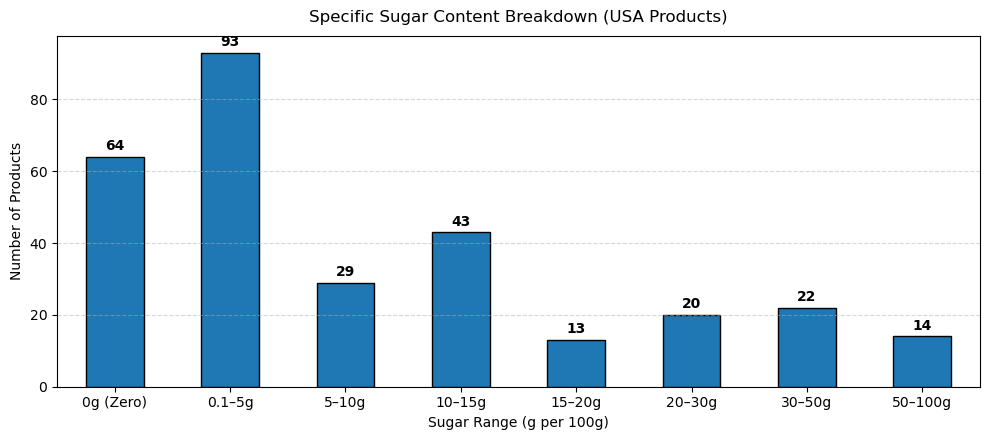

In [78]:
# 1. Filter valid range (0 - 100g)
clean_sugar = usas[usas['sugars_100g'].between(0, 100)]['sugars_100g']

# 2. Define specific, granular ranges
bins = [-0.1, 0, 5, 10, 15, 20, 30, 50, 100]
labels = ['0g (Zero)', '0.1–5g', '5–10g', '10–15g', '15–20g', '20–30g', '30–50g', '50–100g']

sugar_breakdown = pd.cut(clean_sugar, bins=bins, labels=labels).value_counts()[labels]

# 3. Plot specific breakdown with exact numbers
plt.figure(figsize=(10, 4.5))
ax = sugar_breakdown.plot(kind='bar', color='#1f77b4', edgecolor='black')

plt.title('Specific Sugar Content Breakdown (USA Products)', fontsize=12, pad=10)
plt.xlabel('Sugar Range (g per 100g)')
plt.ylabel('Number of Products')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show exact count on top of every bar
for p in ax.patches:
    val = int(p.get_height())
    ax.annotate(str(val), (p.get_x() + p.get_width() / 2., val + 1),
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Energy / Calories in USA Products

In [79]:
usass = usa.copy()
usass.energy_kcal_100g.value_counts()

energy_kcal_100g
0.000000      22
45.833333      7
7.990000       5
148.000000     5
0.676000       5
              ..
23.529412      1
28.169014      1
6.521739       1
50.732807      1
15.200000      1
Name: count, Length: 145, dtype: int64

## Insights

* **Massive Low-Calorie Concentration:** The vast majority of products ($194$ out of $302$) fall in the **$0.1\text{–}50\text{ kcal}$** bracket, with an additional $22$ products having **$0\text{ kcal}$**, showing this dataset heavily consists of low-energy beverages or diet items.
* **Secondary Moderate-Calorie Peak:** A distinct secondary cluster appears in the **$100\text{–}200\text{ kcal}$** range ($49$ products), followed by **$50\text{–}100\text{ kcal}$** ($21$ products), typical for sweetened drinks, juices, or light snacks.
* **Steep Drop in High-Calorie Products:** Calorie-dense items are rare, with counts dropping sharply to $10$ products in **$200\text{–}350\text{ kcal}$**, $4$ in **$350\text{–}500\text{ kcal}$**, and only $2$ reaching **$500+\text{ kcal}$**.

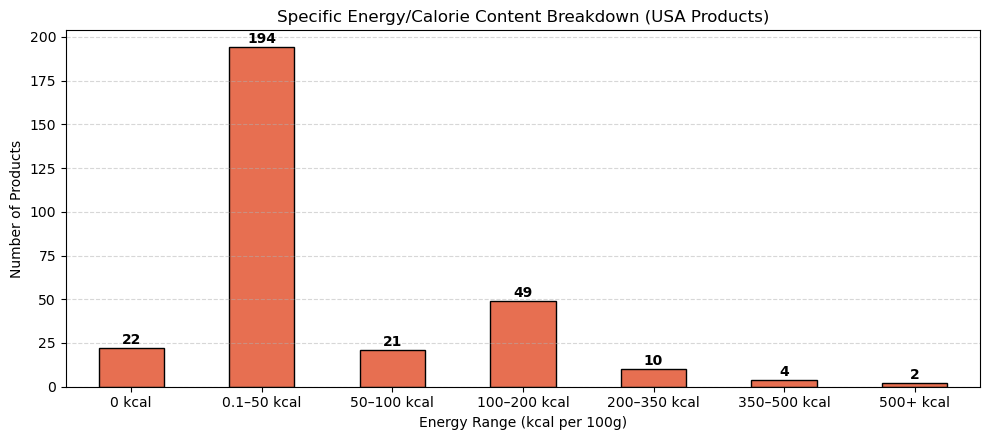

In [82]:
clean_energy = usass[usass['energy_kcal_100g'].between(0, 900)]['energy_kcal_100g']

bins = [-0.1, 0, 50, 100, 200, 350, 500, 900]
labels = ['0 kcal', '0.1–50 kcal', '50–100 kcal', '100–200 kcal', '200–350 kcal', '350–500 kcal', '500+ kcal']
energy_breakdown = pd.cut(clean_energy, bins=bins, labels=labels).value_counts()[labels]

plt.figure(figsize=(10, 4.5))
ax = energy_breakdown.plot(kind='bar', color='#e76f51', edgecolor='black')

plt.title('Specific Energy/Calorie Content Breakdown (USA Products)')
plt.xlabel('Energy Range (kcal per 100g)')
plt.ylabel('Number of Products')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    val = int(p.get_height())
    ax.annotate(str(val), (p.get_x() + p.get_width() / 2., val + 0.5),
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# CANADA Analysis

In [83]:
canada = df[df['countries_tags'].str.contains("canada")]
canada

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,sugars_100g,energy_kcal_100g,packaging_group
10,0059600061904,Limonade,Minute Maid,unknown,"canada, france",unknown,unknown,unknown,unknown,4.0,unknown,"Filtered water, Lemon juice from concentrate, ...",NaN,NaN,Unknown
12,0059600070159,Five Alve,"Minute Maid, Coca-Cola",unknown,canada,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN,Unknown
13,0059600070241,"Jus D'orange (original, Faible En Pulpe)",Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","canada, france",unknown,unknown,unknown,e,1.0,unknown,"EAU FILTRÉE, JUS D'ORANGE CONCENTRÉ.",NaN,NaN,Unknown
19,05965930,Orange Juice,Minute Maid,unknown,canada,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN,Unknown
109,0059600048097,100% Apple Juice from Concentrate with Added V...,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",canada,unknown,Dollarama,"Calgary,Alberta,Canada",e,1.0,unknown,"Filtered water, Concentrated apple juice, Asco...",NaN,NaN,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,0059600070076,minute maid,orange,"plant-based-foods-and-beverages, plant-based-f...",canada,orange,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN,Other
450,0005960000042,Fruitopia® Strawberry Passion Awareness 1.75 L,"Fruitopia,minute maid","plant-based-foods-and-beverages, beverages, pl...",canada,"plastic, cardboard",Maxi,Quebec Canada,e,4.0,unknown,"Filtered Water, Fruit Juices from concentrate ...",NaN,NaN,Other
646,4710018316609,peach flavour sidra,minute maid,unknown,canada,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN,Unknown
665,0059600038579,Orange Juice Zero Sugar,Minute Maid,unknown,canada,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN,Unknown


# Canada Packaging tags Distribution

## Insights

because of insufficient information analysis not possible.

## Canada Nutriscore Grade Analysis

In [75]:
canadaaa = canada.copy()

In [76]:
canadaaa.nutriscore_grade.value_counts()

nutriscore_grade
unknown    52
e           9
c           4
b           2
d           1
Name: count, dtype: int64

In [77]:
canadaaa = canadaaa[canadaaa.nutriscore_grade != 'unknown']
canadaaa.nutriscore_grade.value_counts()

nutriscore_grade
e    9
c    4
b    2
d    1
Name: count, dtype: int64

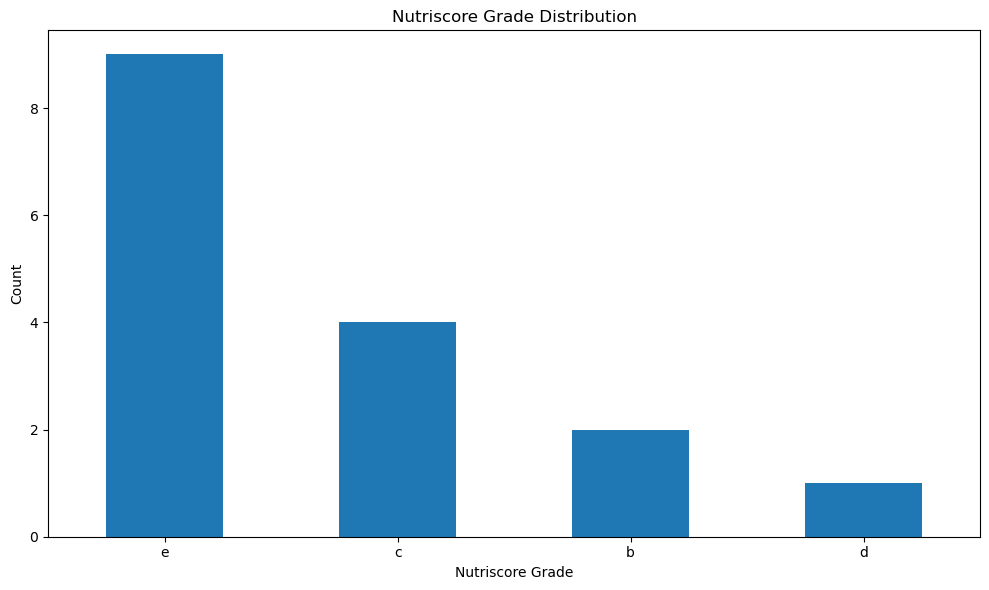

In [78]:
ncounts = canadaaa.nutriscore_grade.value_counts()

plt.figure(figsize=(10, 6))
ncounts.plot(kind='bar')
plt.title('Nutriscore Grade Distribution')
plt.xlabel('Nutriscore Grade')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

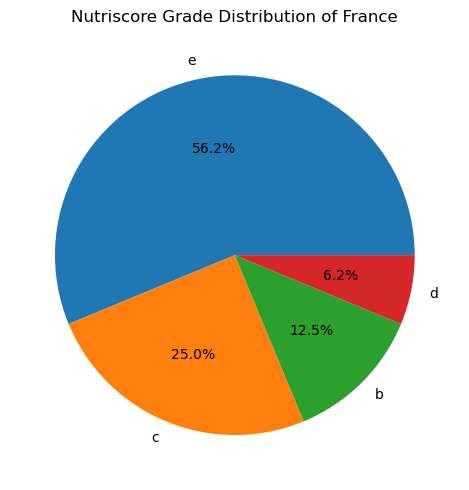

In [79]:
plt.figure(figsize=(5,5))
ncounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nutriscore Grade Distribution of France')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Canada Nova Group Analysis

In [80]:
canadaaaa = canada.copy()

In [81]:
canadaaaa.nova_group.value_counts()

nova_group
4.0    13
1.0     6
3.0     1
Name: count, dtype: int64

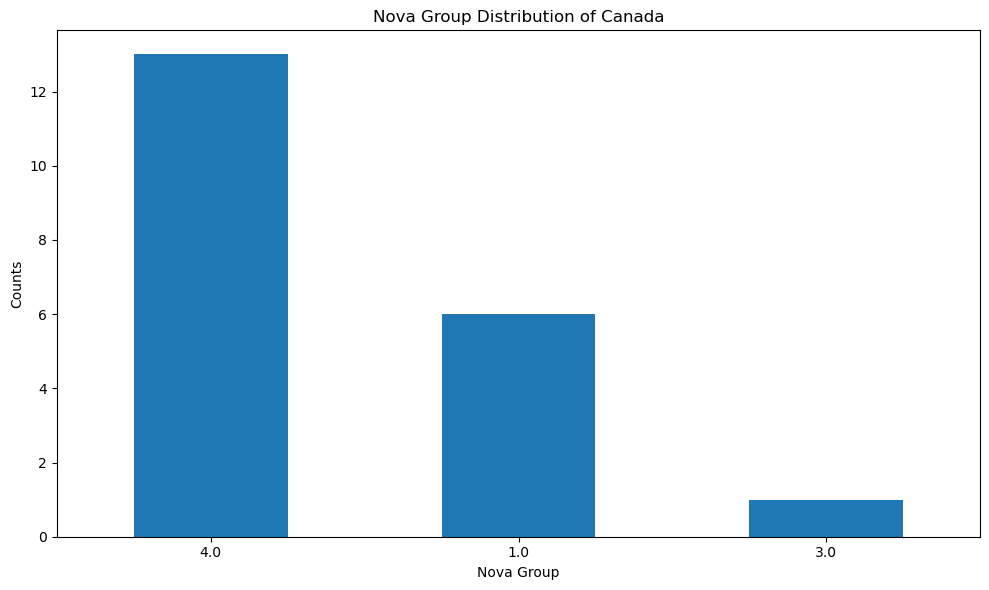

In [82]:
nvcounts = canadaaaa.nova_group.value_counts()

plt.figure(figsize=(10,6))
nvcounts.plot(kind='bar')
plt.title('Nova Group Distribution of Canada')
plt.xlabel('Nova Group')
plt.ylabel('Counts')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

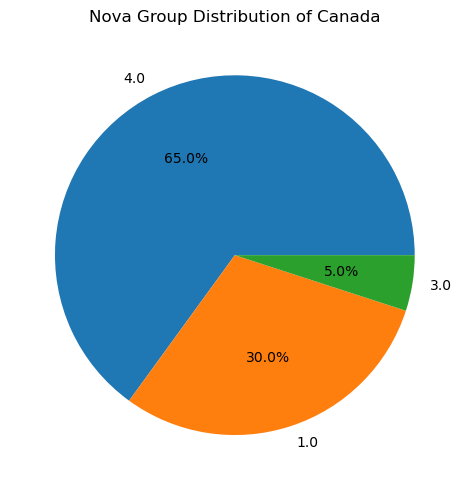

In [83]:
plt.figure(figsize=(5,5))
nvcounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nova Group Distribution of Canada')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [84]:
cansugar = canada.copy()
cansugar.sugars_100g.value_counts()

Series([], Name: count, dtype: int64)

# Suger per 100g distribution in CANADA
## There is no data available for specific CANADA country 

In [87]:
calsugar = canada.copy()

In [88]:
calsugar.energy_kcal_100g.value_counts()

Series([], Name: count, dtype: int64)

# Energy / Calaries in CANADA products 
## There is no data available for specific CANADA country

# All the data cleaning and visualization steps have been completed for the USA and Canada datasets. The next steps could involve further analysis, such as comparing the nutritional content between countries, exploring correlations between different nutritional metrics, or building predictive models based on the available data.